<a href="https://colab.research.google.com/github/val-ium/data-analytics/blob/main/Capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[link text](https://)#Bop or Flop? Predicting Popularity Based on Audio Features.

## Importing and Cleaning

### Loading the Data


In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
"""
This data is sourced from Nidula Elgiriyewithana via Kaggle. I uploaded it to github so I could access without the Kaggle API.

The CSV file contains characters unrecognizable by python. This was overcome by adding encoding='' to the read_csv() function.

"""

In [ ]:
URL = "https://github.com/val-ium/data-analytics/raw/refs/heads/main/spotify-2023.csv"

df = pd.read_csv(URL, encoding = "latin-1")

### Playing with the data



####Creating a new column.

In [ ]:
"""
Becuase I want to calculate royalties, it would be useful to know how many different artists are in each song.
More artists = more splits.

"""

In [61]:
#This is a function that will take a string and count its commas.

def count_artists(artist_string):
  if "," in artist_string:
    return len(artist_string.split(","))
  else:
    return 1


In [62]:
#Now I want to create a column describing how many times a songs royalties are divided.

df["splits"] = df["artist(s)_name"].apply(count_artists)

####Vizualizing Collaborations


<Axes: ylabel='Number of songs with X contributors.'>

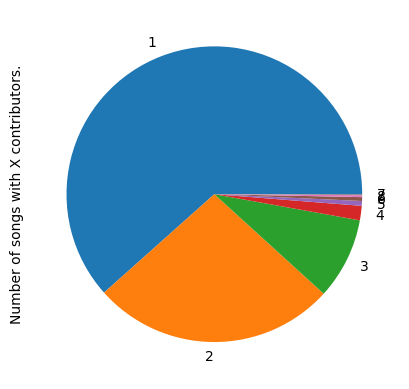

In [81]:
#This chart shows that most songs are solo performances and a minority of songs have multiple artists.

collaboration_distribution = df["splits"].value_counts()

collaboration_distribution.plot(kind = "pie", ylabel= "Number of songs with X contributors.")

## How many songs does each artist have in this data?

In [ ]:
"""
Because features typically pay less than solo entries,  it is useful to
count them seperately. I created a function for future use.


In [56]:
def show_songs(artist_name):

#First I store the entries for a specific artist in a df.

  all_songs = df[df["artist(s)_name"].str.contains(artist_name, case = False)]

#Then I filter which entries are collaborations.

  collabs = all_songs[all_songs["artist(s)_name"].str.contains(",")]

  if len(collabs) == 0:
     print(f"{artist_name} has {len(all_songs)} songs and no collaborations.")
  else:
     print(f"{artist_name} has {len(all_songs)} songs and is featured {len(collabs)} times.")



In [57]:
show_songs("Taylor Swift")

Taylor Swift has 38 songs and is featured 4 times.


## How many splits does an artist have?


In [ ]:
#More artists on a track means less money for each artist.


##How many streams does each artist have?

In [36]:
artist_streams = df.groupby(["artist(s)_name"])["streams"].sum()